In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
owid = pd.read_csv('owid-energy-data.csv')
print('OWID shape: ', owid.shape)

OWID shape:  (23377, 130)


In [3]:
# only countries have iso_code in the csv
owid_countries = owid[owid['iso_code'].notna()].copy()
print('OWID countries only shape: ', owid_countries.shape)

OWID countries only shape:  (17265, 130)


In [4]:
# keeping only columns related to electricity
elec_cols = [ c for c in owid_countries.columns if 'elec' in c or c in ['country', 'iso_code', 'year', 'population', 'gdp'] ]
owid_elec = owid_countries[elec_cols].copy()
print('OWID elec shape: ', owid_elec.shape)

OWID elec shape:  (17265, 52)


In [5]:
# keeping data only from 1985
owid_elec = owid_elec[owid_elec['year']>=1985].copy()
print('Filtered to 1985-2025: ', owid_elec.shape)

Filtered to 1985-2025:  (8715, 52)


In [6]:
cm = pd.read_excel('carbon-monitor-Power-maingraphdatas.xlsx', sheet_name = 'datas')
print('Carbon monitor raw shape: ', cm.shape)

Carbon monitor raw shape:  (128115, 4)


In [7]:
# a few blank rows and a stray footer (site URL + a date stamp) got pulled in from the export. Dropping those rows
valid_countries = {
    'Australia', 'Brazil', 'Chile', 'China', 'EU27 & UK', 'France',
    'Germany', 'India', 'Italy', 'Japan', 'Mexico', 'Russia',
    'South Africa', 'Spain', 'Turkey', 'United Kingdom', 'United States'
}
cm = cm[cm['country'].isin(valid_countries)].copy()
print('Carbon monitor shape after removing junk rows: ', cm.shape)

Carbon monitor shape after removing junk rows:  (128112, 4)


In [8]:
cm['date'] = pd.to_datetime(cm['date'], format = '%d/%m/%Y')

In [9]:
duplicates = cm.duplicated(subset = ['country', 'date', 'sector']).sum()
negatives = (cm['GWh'] < 0).sum()
print(f'No. of duplicates: {duplicates}')
print(f'No. of negative GWh values: {negatives}')

No. of duplicates: 0
No. of negative GWh values: 0


**EDA**

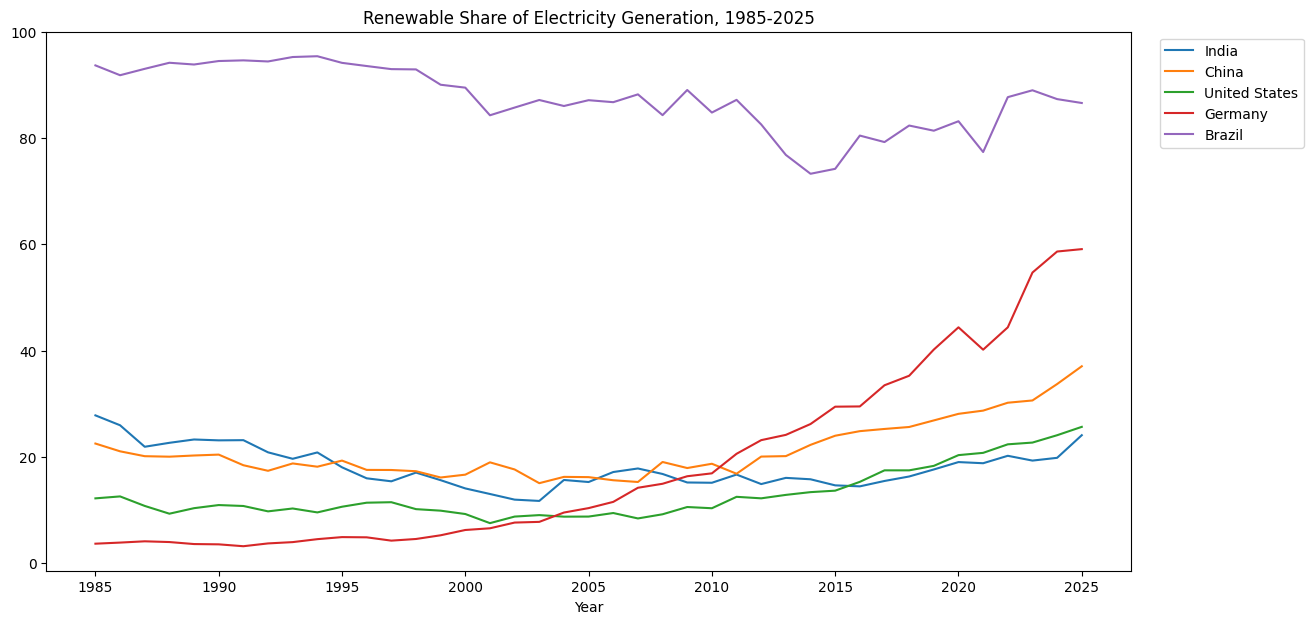

=== INSIGHT 1: India vs peers, renewable share ===
India: 1985=27.8%  -> 2023=19.3%  (-8.5 pts)
China: 1985=22.5%  -> 2023=30.6%  (+8.1 pts)
United States: 1985=12.2%  -> 2023=22.7%  (+10.5 pts)
Germany: 1985=3.6%  -> 2023=54.7%  (+51.0 pts)
Brazil: 1985=93.7%  -> 2023=89.0%  (-4.7 pts)



In [10]:
peers = ['India', 'China', 'United States', 'Germany', 'Brazil']
peer_data = owid_elec[owid_elec['country'].isin(peers)].copy()
plt.figure(figsize=(14,7))
for country in peers:
  sub = peer_data[peer_data['country'] == country].sort_values('year')
  plt.plot(sub['year'], sub['renewables_share_elec'], label=country)
plt.title('Renewable Share of Electricity Generation, 1985-2025')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.02, 1))
plt.show()

print("=== INSIGHT 1: India vs peers, renewable share ===")
for country in peers:
    sub = peer_data[peer_data['country'] == country].sort_values('year')
    start = sub.iloc[0]
    end = sub[sub['year'] <= 2023].iloc[-1]  # 2023 = full coverage year
    print(f"{country}: {start['year']}={start['renewables_share_elec']:.1f}%  "
          f"-> 2023={end['renewables_share_elec']:.1f}%  "
          f"({end['renewables_share_elec']-start['renewables_share_elec']:+.1f} pts)")
print()

In [11]:
snapshot_year = 2023 # 2023 is the recent year that has most no. of countries
snap = owid_elec[owid_elec['year'] == snapshot_year].copy()
snap = snap[snap['electricity_generation'] > 0]  # drop countries with no generation data that year

top10_renewable = snap.sort_values('renewables_share_elec', ascending=False).head(10)
bottom10_renewable = snap[snap['electricity_generation'] > snap['electricity_generation'].quantile(0.25)] \
    .sort_values('renewables_share_elec', ascending=True).head(10)

print(f"=== INSIGHT 2: Top 10 countries by renewable share ({snapshot_year}) ===")
print(top10_renewable[['country', 'renewables_share_elec']].to_string(index=False))
print(f"\n=== Bottom 10 (excluding smallest generators) by renewable share ({snapshot_year}) ===")
print(bottom10_renewable[['country', 'renewables_share_elec']].to_string(index=False))

india_rank = snap.sort_values('renewables_share_elec', ascending=False).reset_index(drop=True)
india_position = india_rank[india_rank['country'] == 'India'].index[0] + 1
print(f"\nIndia's global rank by renewable share ({snapshot_year}): #{india_position} of {len(india_rank)}")
print()

=== INSIGHT 2: Top 10 countries by renewable share (2023) ===
                     country  renewables_share_elec
                     Albania                100.000
                      Bhutan                100.000
Democratic Republic of Congo                100.000
                    Ethiopia                100.000
    Central African Republic                100.000
                     Iceland                100.000
                       Nepal                100.000
                    Paraguay                100.000
                  Costa Rica                 99.915
                      Norway                 98.470

=== Bottom 10 (excluding smallest generators) by renewable share (2023) ===
            country  renewables_share_elec
             Brunei                  0.000
              Libya                  0.030
       Turkmenistan                  0.031
Trinidad and Tobago                  0.105
            Bahrain                  0.240
           Botswana            

In [12]:
cm_totals = cm.groupby(['country', 'sector'])['GWh'].sum().reset_index()
cm_pivot = cm_totals.pivot(index='country', columns='sector', values='GWh').fillna(0)
renewable_sectors = ['Solar', 'Wind', 'Hydroelectricity']
cm_pivot['total'] = cm_pivot.sum(axis=1)
cm_pivot['renewable_share'] = (cm_pivot[renewable_sectors].sum(axis=1) / cm_pivot['total'])*100
cm_pivot = cm_pivot.sort_values('renewable_share', ascending=False)
print("=== INSIGHT 3: Renewable share by country, CarbonMonitor (2024-2026 window) ===")
print(cm_pivot[['renewable_share']].round(1).to_string())
print()


=== INSIGHT 3: Renewable share by country, CarbonMonitor (2024-2026 window) ===
sector          renewable_share
country                        
Brazil                     87.8
Chile                      63.8
Spain                      58.9
Germany                    53.2
EU27 & UK                  43.6
Australia                  41.4
Italy                      41.2
United Kingdom             40.6
Turkey                     37.9
China                      33.5
France                     26.9
United States              23.2
India                      21.3
Japan                      20.4
Mexico                     19.0
Russia                     18.2
South Africa               11.3



In [13]:
common_countries = set(snap['country']) & set(cm_pivot.index)
comparison = pd.DataFrame({
    'owid_2023': snap.set_index('country').loc[list(common_countries), 'renewables_share_elec'],
    'carbonmonitor_2024_26': cm_pivot.loc[list(common_countries), 'renewable_share']
}).sort_values('owid_2023', ascending=False)

print("=== INSIGHT 4: Cross-check - do the two sources roughly agree? ===")
print(comparison.round(1))
correlation = comparison['owid_2023'].corr(comparison['carbonmonitor_2024_26'])
print(f"\nCorrelation between the two sources' country rankings: {correlation:.2f}")
print("(Close to 1.0 = sources agree well; note OWID counts biofuel as renewable")
print(" while CarbonMonitor's 'renewable_share' here only counts Solar+Wind+Hydro,")
print(" so some gap is expected, not necessarily an error.)\n")

=== INSIGHT 4: Cross-check - do the two sources roughly agree? ===
                owid_2023  carbonmonitor_2024_26
country                                         
Brazil               89.0                   87.8
Chile                63.1                   63.8
Germany              54.7                   53.2
Spain                51.5                   58.9
United Kingdom       46.4                   40.6
Italy                44.6                   41.2
Turkey               42.0                   37.9
Australia            34.8                   41.4
China                30.6                   33.5
France               26.9                   26.9
United States        22.7                   23.2
Japan                22.1                   20.4
Mexico               20.3                   19.0
India                19.3                   21.3
Russia               17.7                   18.2
South Africa         12.4                   11.3

Correlation between the two sources' country ranki

In [14]:
first = owid[owid['year'] == 1985][['country', 'renewables_share_elec']].rename(
    columns={'renewables_share_elec': 'share_1985'})
last = owid[owid['year'] == 2023][['country', 'renewables_share_elec']].rename(
    columns={'renewables_share_elec': 'share_2023'})
growth = first.merge(last, on='country').dropna()
growth['change'] = growth['share_2023'] - growth['share_1985']

# Filter to countries with meaningful current generation, same logic as before
sizable = snap[snap['electricity_generation'] > snap['electricity_generation'].quantile(0.5)]['country']
growth_sizable = growth[growth['country'].isin(sizable)].sort_values('change', ascending=False)

print("=== INSIGHT 5: Fastest renewable share growth, 1985-2023 (sizable generators only) ===")
print(growth_sizable.head(10).to_string(index=False))


=== INSIGHT 5: Fastest renewable share growth, 1985-2023 (sizable generators only) ===
       country  share_1985  share_2023  change
       Denmark       0.402      86.397  85.995
       Germany       3.645      54.685  51.040
   Netherlands       0.705      47.382  46.677
United Kingdom       1.327      46.378  45.051
     Venezuela      47.892      90.342  42.450
        Greece      10.112      49.826  39.714
       Ireland       6.927      45.261  38.334
       Belgium       0.593      33.435  32.842
       Romania      17.702      49.798  32.096
       Finland      24.971      51.889  26.918


In [15]:
owid_elec.to_csv('owid_electricity_cleaned.csv', index=False)

In [16]:
cm.to_csv('carbonmonitor_cleaned.csv', index=False)

In [17]:


statetype = pd.read_csv('india_power_statetype_monthly.csv')
statetype['year_month'] = pd.PeriodIndex(statetype['year_month'], freq='M')
statetype['year'] = statetype['year_month'].dt.year

thermal = statetype[statetype['station_type']=='Thermal'].groupby('year').agg(
    total_prgm=('total_prgm','sum'), total_shortfall=('total_shortfall','sum')
).reset_index()
thermal['thermal_shortfall_pct'] = thermal['total_shortfall']/thermal['total_prgm']*100

# owid = pd.read_csv('owid_electricity_cleaned.csv')
india_owid = owid_elec[owid_elec['country']=='India'][['year','renewables_share_elec']]

merged = thermal.merge(india_owid, on='year', how='inner')
merged = merged[~merged['year'].isin([2017, 2025])]  # drop partial years, as before
merged.to_csv('india_correlation_test.csv', index=False)
print(merged)

   year  total_prgm  total_shortfall  thermal_shortfall_pct  \
1  2018  1028703.93          7444.23               0.723651   
2  2019  1077804.85         88562.08               8.216894   
3  2020   846882.07         64684.30               7.637935   
4  2021  1105338.34         33916.32               3.068411   
5  2022  1187749.51         23710.73               1.996274   
6  2023  1267637.39          3742.45               0.295230   
7  2024  1310632.78         57623.30               4.396601   

   renewables_share_elec  
1                 16.294  
2                 17.617  
3                 19.007  
4                 18.791  
5                 20.190  
6                 19.287  
7                 19.808  
